# Los mismos métodos con 132 casos

**Unidad 9 · Machine Learning · Notebook 3b de 6 · contrapunto de `9.3`**

En `9.3` los ensambles ganaron. Este notebook corre **el mismo código** sobre la encuesta de 132
casos de `9.2` y llega a la conclusión opuesta.

## Por qué este notebook existe

`9.3` mostró la progresión completa sobre 7.233 mesas: árbol de profundidad 3 en 0.666, árbol
calibrado en 0.749, Random Forest en 0.772, XGBoost en 0.775 contra un baseline de 0.503. La
lectura natural es "los ensambles funcionan".

El problema es que **7.233 casos no es el tamaño de muestra con el que trabaja un analista de
opinión pública.** Una encuesta propia tiene 400, 800, a veces 1.200 casos. Un relevamiento
exploratorio como el de `9.2`, 132.

Entonces la pregunta que este notebook responde es la que importa para el trabajo real:

> **¿La conclusión de `9.3` sobrevive cuando el n es el que uno tiene de verdad?**

La teoría de los tres métodos —impureza, ganancia de información, poda, bagging, decorrelación,
gradiente, los hiperparámetros de cada uno— está desarrollada en `9.3`. Acá no se repite: se usa.

## Requisitos

In [1]:
# Requisitos de este notebook.
# Si te falta alguno, instalalo EN TU PROPIO ENTORNO desde una terminal
# (o descomentando la linea de abajo) y reinicia el kernel:
#
#     pip install numpy pandas matplotlib seaborn scikit-learn statsmodels xgboost
#
# %pip install numpy pandas matplotlib seaborn scikit-learn statsmodels xgboost

import importlib

_requeridos = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn', 'statsmodels', 'xgboost']
_faltan = []
for _m in _requeridos:
    try:
        _mod = importlib.import_module(_m)
        print(f"  {_m:16s} {getattr(_mod, '__version__', 'sin version')}")
    except ImportError:
        _faltan.append(_m)
        print(f"  {_m:16s} FALTA")

if _faltan:
    print(f"\nFaltan {len(_faltan)} paquetes: {', '.join(_faltan)}.")
    print("Instalalos en tu entorno antes de seguir.")
else:
    print("\nTodo listo.")

  numpy            1.26.4
  pandas           2.2.2


  matplotlib       3.9.2


  seaborn          0.13.2


  sklearn          1.9.0
  statsmodels      0.14.2


  xgboost          3.4.1

Todo listo.


## Librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (AdaBoostClassifier, GradientBoostingClassifier,
                              RandomForestClassifier)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold,
                                     cross_validate, learning_curve, train_test_split,
                                     validation_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

from scipy.optimize import curve_fit
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.width", 200)

SEED = 42
rng = np.random.default_rng(SEED)
PALETA = ["#0073C2", "#EFC000", "#CD534C", "#868686", "#1E2749"]

## Los datos

Los mismos de `9.2`, con la misma depuración: se descartan las dos etiquetas inválidas, se
excluyen `NH_EDAD`, `TH_EDAD` y `N_BUSCA_HIJOS` por errores del cuestionario, se saca `UP` por
varianza casi nula, y los faltantes estructurales se codifican en lugar de imputarse. La
justificación de cada decisión está en `9.2`.

In [3]:
datos = pd.read_excel("../../dataset/encuesta134/134NODUMMY.xlsx")
datos = datos[~datos["ETIQUETA"].isin(["Linda", "Es una verga la política"])].reset_index(drop=True)

datos["HIJOS_COMB"] = np.where(
    datos["HIJOS"] == 1, 1.0,
    np.where((datos["HIJOS"] == 0) & (datos["BUSCA_HIJOS"] == 1), 1.0,
             np.where(datos["BUSCA_HIJOS"].isna(), np.nan, 0.0)))
datos["PROBLEMA_RAMA"] = np.where(
    datos["EL_PROBLEMA"] == 1,
    np.where(datos["DESIGUALDAD"] == 1, "concentracion_riqueza_si", "concentracion_riqueza_no"),
    np.where(datos["NO_PIENSAN"] == 1, "no_piensan_si", "no_piensan_no"))
for col in ["GRUPO", "PROLE"]:
    datos[col] = datos[col].fillna("No aplica / no trabaja")

BINARIAS = ["MASCOTHIJO", "GORRA", "EF", "EJERCITO", "TARIFAS", "EMPRESARIOS",
            "MALVINAS", "EF_QUEES", "EL_PROBLEMA", "GENERO", "TRABAJA", "HIJOS"]
ORDINALES = ["EEUU", "PALESTINA", "ISRAEL", "UCRANIA", "RUSIA", "BOLIVIA", "CHINA",
             "INGLATERRA", "EDAD", "ESTUDIO", "SOCIECON"]
CATEGORICAS = ["SS", "PROGRAMA", "NOTICIAS", "GRUPO", "PROLE", "NO_HIJOS_PQ",
               "PROBLEMA_RAMA"]
NUMERICAS = BINARIAS + ORDINALES + ["HIJOS_COMB"]

X = datos[NUMERICAS + CATEGORICAS].copy()
X[NUMERICAS] = X[NUMERICAS].astype(float)

y_7 = datos["ETIQUETA"]
y_2 = pd.Series(np.where(y_7 == "Peronista", "Peronista", "No peronista"), index=y_7.index)
MAPA_3 = {"Peronista": "Peronismo/Izquierda", "De izquierda": "Peronismo/Izquierda",
          "Liberal": "Derecha/Liberal", "De derecha": "Derecha/Liberal",
          "Radical": "Sin adscripción clara", "Apolitico": "Sin adscripción clara",
          "No sabe/ No contesta": "Sin adscripción clara"}
y_3 = y_7.map(MAPA_3)

preprocesador = ColumnTransformer([
    ("num", Pipeline([("imputar", SimpleImputer(strategy="median")),
                      ("escalar", StandardScaler())]), NUMERICAS),
    ("cat", Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),
                      ("dummies", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                                min_frequency=6,
                                                sparse_output=False))]), CATEGORICAS),
])

X_mat = preprocesador.fit_transform(X)
print(f"n = {len(X)}   matriz de diseño: {X_mat.shape}")
print(f"baseline 2 clases: {y_2.value_counts(normalize=True).iloc[0]:.3f}")
print(f"\nRelación p/n = {X_mat.shape[1] / len(X):.2f}   "
      f"(en 9.3 era {62 / 7233:.3f})")

n = 132   matriz de diseño: (132, 56)
baseline 2 clases: 0.545

Relación p/n = 0.42   (en 9.3 era 0.009)


Ahí está la diferencia de fondo, en una sola línea: en `9.3` había **117 observaciones por cada
columna** de la matriz de diseño. Acá hay **2.4**. Todo lo que sigue se explica por ese número.

In [4]:
CV = RepeatedStratifiedKFold(n_splits=5, n_repeats=6, random_state=SEED)
METRICAS = ["accuracy", "f1_macro", "balanced_accuracy"]

def con_arbol(modelo):
    return Pipeline([("pre", preprocesador), ("clf", modelo)])

def evaluar(estimador, X, y, nombre):
    r = cross_validate(estimador, X, y, cv=CV, scoring=METRICAS, n_jobs=-1)
    return {"modelo": nombre,
            "exactitud": r["test_accuracy"].mean(),
            "exac_sd": r["test_accuracy"].std(),
            "f1_macro": r["test_f1_macro"].mean(),
            "f1_sd": r["test_f1_macro"].std()}

## Primer síntoma: la curva de validación no dice nada

En `9.3` la curva de validación sobre `max_depth` tenía un máximo nítido y una brecha creciente
entre entrenamiento y validación. Es la figura canónica del compromiso sesgo-varianza.

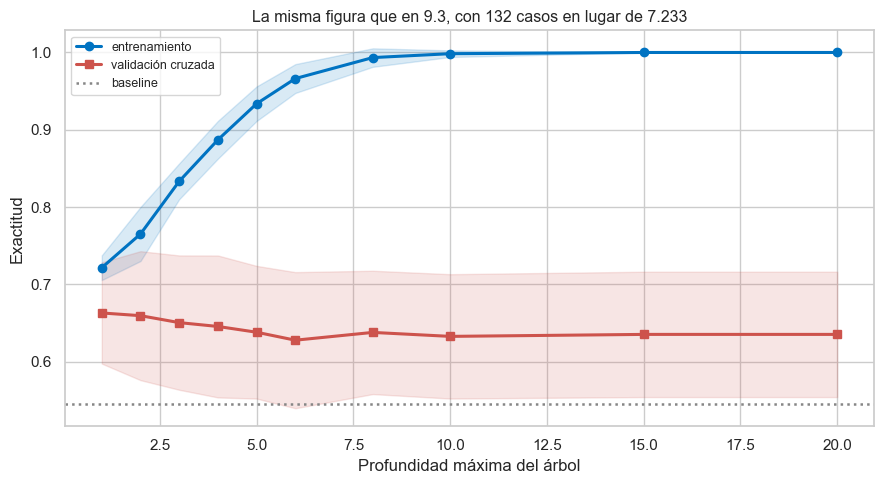

exactitud de validación: mínimo 0.628, máximo 0.663   (rango de 0.035)
desvío típico entre pliegues: 0.082


In [5]:
profundidades = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20]
tr, te = validation_curve(
    con_arbol(DecisionTreeClassifier(random_state=SEED)),
    X, y_2, param_name="clf__max_depth", param_range=profundidades,
    cv=CV, scoring="accuracy", n_jobs=-1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(profundidades, tr.mean(axis=1), "o-", lw=2.2, color=PALETA[0], label="entrenamiento")
ax.fill_between(profundidades, tr.mean(axis=1) - tr.std(axis=1),
                tr.mean(axis=1) + tr.std(axis=1), alpha=0.15, color=PALETA[0])
ax.plot(profundidades, te.mean(axis=1), "s-", lw=2.2, color=PALETA[2], label="validación cruzada")
ax.fill_between(profundidades, te.mean(axis=1) - te.std(axis=1),
                te.mean(axis=1) + te.std(axis=1), alpha=0.15, color=PALETA[2])
ax.axhline(y_2.value_counts(normalize=True).iloc[0], color=PALETA[3], ls=":", lw=1.8,
           label="baseline")
ax.set_xlabel("Profundidad máxima del árbol")
ax.set_ylabel("Exactitud")
ax.set_title("La misma figura que en 9.3, con 132 casos en lugar de 7.233", fontsize=11.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"exactitud de validación: mínimo {te.mean(axis=1).min():.3f}, "
      f"máximo {te.mean(axis=1).max():.3f}   (rango de {te.mean(axis=1).ptp():.3f})")
print(f"desvío típico entre pliegues: {te.std(axis=1).mean():.3f}")

La curva de validación es **plana dentro del ruido**: todo el rango que recorre al variar la
profundidad de 1 a 20 es del mismo orden que el desvío entre pliegues. No hay un óptimo
identificable, y elegir `max_depth` con esta curva sería elegir ruido.

El entrenamiento, en cambio, llega a **1.0**: el árbol memoriza los 132 casos sin esfuerzo.

Esto no es un defecto del gráfico. Es la información de que **con esta muestra no se puede
calibrar la complejidad del modelo**, que es un problema serio y no siempre visible.

## Segundo síntoma: el árbol es completamente inestable

En `9.3` la variable de la raíz era siempre la misma —la participación— y solo cambiaban los
cortes de abajo. Acá cambia todo.

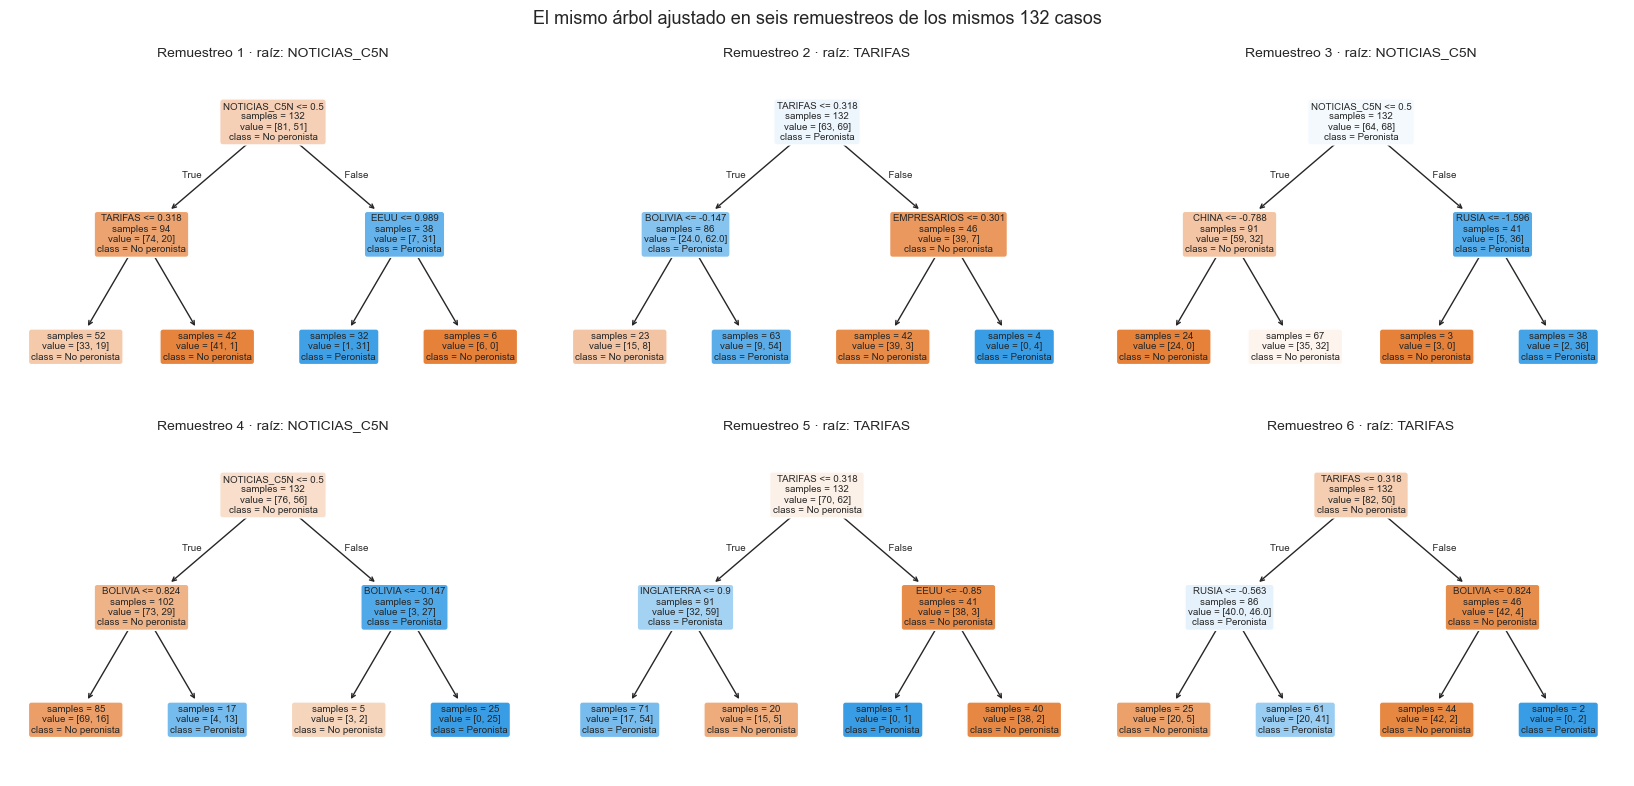

Variable de la raíz en cada remuestreo:
  1. NOTICIAS_C5N
  2. TARIFAS
  3. NOTICIAS_C5N
  4. NOTICIAS_C5N
  5. TARIFAS
  6. TARIFAS

variables distintas en la raíz: 2 de 6 remuestreos


In [6]:
nombres = [n.split("__", 1)[1] for n in
           con_arbol(DecisionTreeClassifier()).fit(X, y_2)[:-1].get_feature_names_out()]

fig, axes = plt.subplots(2, 3, figsize=(16.5, 8))
raices = []
for k, ax in enumerate(axes.ravel()):
    idx = rng.integers(0, len(X), len(X))
    t = DecisionTreeClassifier(max_depth=2, random_state=SEED).fit(X_mat[idx], y_2.iloc[idx])
    plot_tree(t, feature_names=list(nombres), class_names=list(t.classes_),
              filled=True, rounded=True, fontsize=7, ax=ax, impurity=False)
    raiz = nombres[t.tree_.feature[0]]
    raices.append(raiz)
    ax.set_title(f"Remuestreo {k + 1} · raíz: {raiz}", fontsize=10)

fig.suptitle("El mismo árbol ajustado en seis remuestreos de los mismos 132 casos", fontsize=13)
plt.tight_layout()
plt.show()

print("Variable de la raíz en cada remuestreo:")
for k, r in enumerate(raices, 1):
    print(f"  {k}. {r}")
print(f"\nvariables distintas en la raíz: {len(set(raices))} de 6 remuestreos")

La raíz cambia entre remuestreos de los **mismos** datos. Y la raíz es la decisión **más estable**
de un árbol: hacia abajo la variabilidad es mayor.

Eso tiene una consecuencia directa sobre cómo se comunica un resultado. Si se dicta un árbol
ajustado a una encuesta de este tamaño y se concluye "la variable determinante es X", esa
conclusión no sobrevive a un remuestreo de los propios datos. **La estructura de un árbol
particular sobre 132 casos no es un hallazgo.**

## La comparación

Todos los modelos bajo la misma validación cruzada, con el logit regularizado de `9.2` como
referencia.

In [7]:
LOGIT_92 = LogisticRegression(C=0.2081, l1_ratio=0.5, solver="saga",
                              max_iter=20000, random_state=SEED)

modelos = [
    ("BASELINE (clase mayoritaria)", DummyClassifier(strategy="most_frequent")),
    ("Logit regularizado (9.2)", con_arbol(LOGIT_92)),
    ("Árbol prof. 2", con_arbol(DecisionTreeClassifier(max_depth=2, random_state=SEED))),
    ("Árbol prof. 5", con_arbol(DecisionTreeClassifier(max_depth=5, random_state=SEED))),
    ("Árbol sin podar", con_arbol(DecisionTreeClassifier(random_state=SEED))),
    ("AdaBoost (100 tocones)",
     con_arbol(AdaBoostClassifier(
         estimator=DecisionTreeClassifier(max_depth=1, random_state=SEED),
         n_estimators=100, random_state=SEED))),
    ("Gradient Boosting",
     con_arbol(GradientBoostingClassifier(max_depth=3, n_estimators=200,
                                          learning_rate=0.05, random_state=SEED))),
    ("Random Forest (500)",
     con_arbol(RandomForestClassifier(n_estimators=500, random_state=SEED, n_jobs=-1))),
    ("Random Forest, hojas ≥ 5",
     con_arbol(RandomForestClassifier(n_estimators=500, min_samples_leaf=5,
                                      random_state=SEED, n_jobs=-1))),
]

filas = [evaluar(est, X, y_2, nombre) for nombre, est in modelos]

y_2b = (y_2 == "Peronista").astype(int)
r = cross_validate(con_arbol(XGBClassifier(n_estimators=200, max_depth=3,
                                           learning_rate=0.05, subsample=0.8,
                                           colsample_bytree=0.8, reg_lambda=1.0,
                                           eval_metric="logloss", random_state=SEED,
                                           n_jobs=-1)),
                   X, y_2b, cv=CV, scoring=METRICAS, n_jobs=-1)
filas.append({"modelo": "XGBoost (200)",
              "exactitud": r["test_accuracy"].mean(),
              "exac_sd": r["test_accuracy"].std(),
              "f1_macro": r["test_f1_macro"].mean(),
              "f1_sd": r["test_f1_macro"].std()})

tabla = pd.DataFrame(filas).sort_values("exactitud", ascending=False).reset_index(drop=True)
tabla.round(3)

,modelo,exactitud,exac_sd,f1_macro,f1_sd
0,Logit regularizado (9.2),0.791,0.069,0.787,0.070
1,Random Forest (500),0.788,0.068,0.784,0.069
2,"Random Forest, hojas ≥ 5",0.778,0.046,0.771,0.049
3,XGBoost (200),0.765,0.074,0.760,0.077
4,Gradient Boosting,0.734,0.069,0.729,0.070
5,AdaBoost (100 tocones),0.734,0.069,0.728,0.071
6,Árbol prof. 2,0.660,0.083,0.630,0.095
7,Árbol prof. 5,0.638,0.086,0.632,0.089
8,Árbol sin podar,0.635,0.081,0.631,0.083
9,BASELINE (clase mayoritaria),0.545,0.008,0.353,0.003


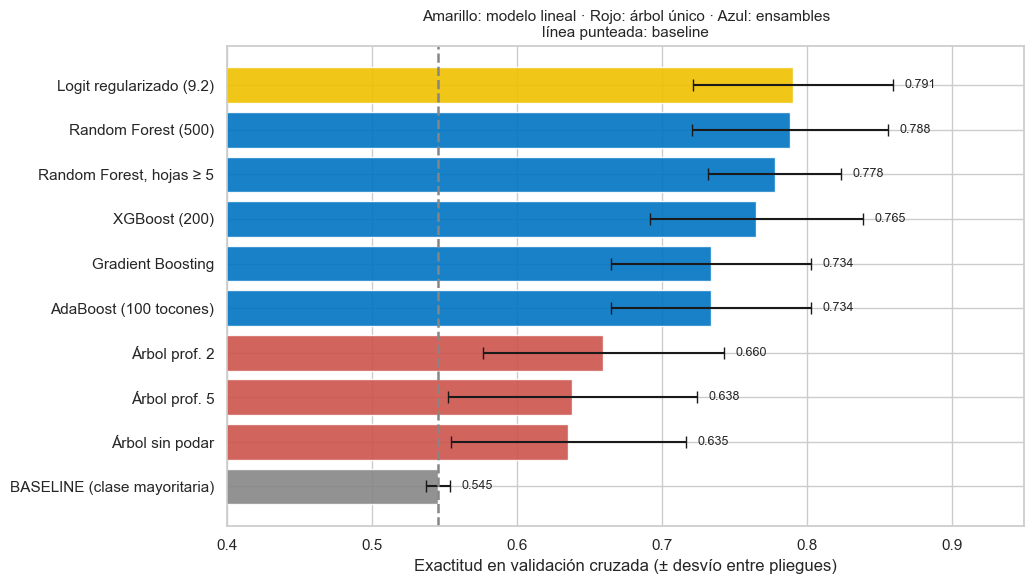

In [8]:
fig, ax = plt.subplots(figsize=(10.5, 6))
t = tabla.sort_values("exactitud")
colores = []
for m in t["modelo"]:
    if m.startswith("BASELINE"):
        colores.append(PALETA[3])
    elif "Logit" in m:
        colores.append(PALETA[1])
    elif "Árbol" in m:
        colores.append(PALETA[2])
    else:
        colores.append(PALETA[0])

ax.barh(t["modelo"], t["exactitud"], xerr=t["exac_sd"], capsize=4, color=colores, alpha=0.9)
ax.axvline(tabla.loc[tabla["modelo"].str.startswith("BASELINE"), "exactitud"].iloc[0],
           color=PALETA[3], ls="--", lw=1.8)
ax.set_xlim(0.4, 0.95)
ax.set_xlabel("Exactitud en validación cruzada (± desvío entre pliegues)")
ax.set_title("Amarillo: modelo lineal · Rojo: árbol único · Azul: ensambles\n"
             "línea punteada: baseline", fontsize=11)
for i, (v, s) in enumerate(zip(t["exactitud"], t["exac_sd"])):
    ax.text(v + s + 0.008, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

### El veredicto se invirtió

1. **Random Forest y el logit regularizado empatan.** Alrededor de 0.79 los dos, con desvíos de
   0.07. La diferencia entre ellos es un orden de magnitud menor que el desvío: son
   indistinguibles.
2. **Los árboles individuales quedan 13 puntos abajo**, entre 0.63 y 0.67. Ninguna profundidad los
   rescata.
3. **XGBoost queda por detrás de Random Forest.** Con 132 casos, un método que suma cientos de
   correcciones secuenciales tiene demasiada capacidad para tan pocos datos.
4. Todos los ensambles le ganan holgadamente al baseline de 0.545, así que **sí hay señal**: lo
   que no hay es ventaja de la flexibilidad.

Comparado con `9.3`, donde XGBoost ganaba y la logística quedaba tercera, el orden se dio vuelta
casi por completo.

**Y eso es un hallazgo sobre los datos, no un fracaso del método.** Que un bosque de 500 árboles
no le saque ventaja a una frontera lineal significa que **la relación entre estas opiniones y la
identificación política es aproximadamente lineal en el logit**, sin interacciones fuertes que el
modelo lineal esté perdiendo. En `9.3` sí las había —el efecto de la participación dependía del
barrio— y ahí los ensambles ganaron.

In [9]:
# ¿El veredicto depende de cuántas clases tenga la etiqueta?
comparacion_multi = []
for nombre_esq, yy in [("7 clases", y_7), ("3 clases", y_3), ("2 clases", y_2)]:
    for nombre_mod, est in [
            ("Baseline", DummyClassifier(strategy="most_frequent")),
            ("Árbol prof. 3", con_arbol(DecisionTreeClassifier(max_depth=3,
                                                               random_state=SEED))),
            ("Logit reg.", con_arbol(LOGIT_92)),
            ("Random Forest", con_arbol(RandomForestClassifier(n_estimators=500,
                                                               random_state=SEED,
                                                               n_jobs=-1)))]:
        f = evaluar(est, X, yy, nombre_mod)
        f["esquema"] = nombre_esq
        comparacion_multi.append(f)

pivote = pd.DataFrame(comparacion_multi).pivot(index="modelo", columns="esquema",
                                               values="exactitud")
pivote.loc[["Baseline", "Árbol prof. 3", "Logit reg.", "Random Forest"],
           ["7 clases", "3 clases", "2 clases"]].round(3)

esquema,7 clases,3 clases,2 clases
modelo,,,
Baseline,0.455,0.599,0.545
Árbol prof. 3,0.397,0.632,0.651
Logit reg.,0.513,0.712,0.791
Random Forest,0.517,0.726,0.788


El patrón se repite en los tres esquemas, y con 7 clases pasa algo que vale detenerse a mirar:
**el árbol de profundidad 3 queda por debajo del baseline.**

No es un error. El baseline predice siempre la clase mayoritaria y por eso acierta el 45.5%
garantizado. El árbol intenta discriminar, hace cortes basados en una o dos observaciones de las
clases chicas, y se equivoca en casos que el baseline habría acertado por default. Con 7 clases y
132 casos, **intentar discriminar es peor que no intentarlo**.

Random Forest no cae en eso porque promedia: al votar entre 500 árboles, las decisiones basadas en
un solo caso se diluyen. Es exactamente para lo que sirve el bagging.

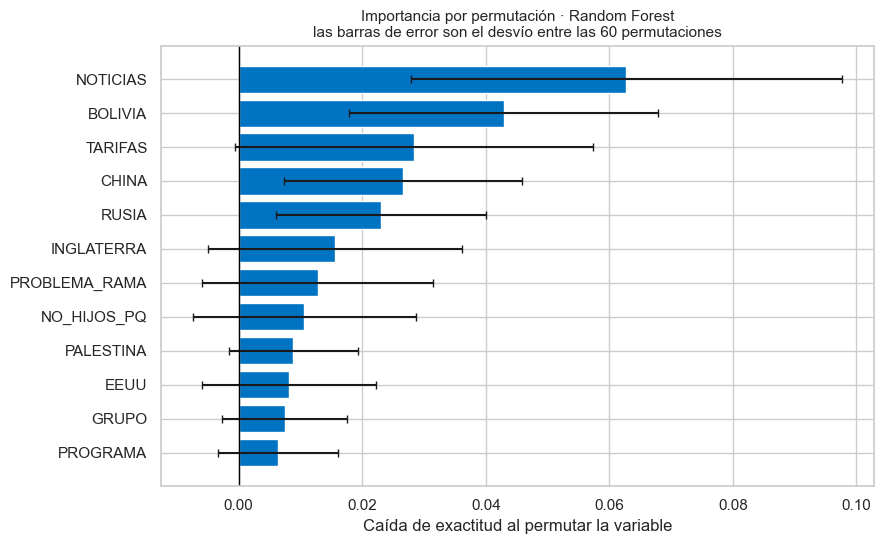

In [10]:
# Qué variables usa el bosque, medido correctamente
rf_final = con_arbol(RandomForestClassifier(n_estimators=500, min_samples_leaf=5,
                                            random_state=SEED, n_jobs=-1))
X_tr, X_te, y_tr, y_te = train_test_split(X, y_2, test_size=0.35,
                                          random_state=SEED, stratify=y_2)
rf_final.fit(X_tr, y_tr)

perm = permutation_importance(rf_final, X_te, y_te, n_repeats=60, random_state=SEED,
                              scoring="accuracy", n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
sd = pd.Series(perm.importances_std, index=X.columns)

top = imp.head(12).sort_values()
fig, ax = plt.subplots(figsize=(9, 5.6))
ax.barh(top.index, top.values, xerr=sd[top.index], capsize=3,
        color=[PALETA[0] if v > 0 else PALETA[3] for v in top.values])
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Caída de exactitud al permutar la variable")
ax.set_title("Importancia por permutación · Random Forest\n"
             "las barras de error son el desvío entre las 60 permutaciones", fontsize=11)
plt.tight_layout()
plt.show()

`TARIFAS` encabeza el ranking, y es el mismo predictor que en `9.2` tenía el *odds ratio* más
extremo (0.106) y el efecto marginal más grande (−31 puntos porcentuales). Tres métodos con
maquinarias completamente distintas —logit, árbol, bosque— señalan la misma variable. Eso es lo
más parecido a una validación que se puede tener con 132 casos.

Notar también que **casi todas las barras de error cruzan el cero**: con un conjunto de validación
de 47 casos, la importancia de cada variable individual se estima con muchísimo ruido.

## Cierre aplicado: cuántos casos harían falta

El producto de este notebook no es un clasificador —el logit de `9.2` empata con el bosque y es
más simple e interpretable—. Es una **decisión de diseño de investigación**: ¿vale la pena relevar
más casos, y cuántos?

Las curvas de aprendizaje suelen seguir aproximadamente una ley de potencias:

$$ \text{error}(n) \approx a \cdot n^{-b} + c $$

donde $c$ es el **error asintótico**: el piso que no baja por más datos que se agreguen, porque
depende de qué variables se midieron y de cuánta aleatoriedad irreducible tiene el fenómeno.

Ajustamos esa curva de dos maneras, y la comparación entre las dos es la parte honesta del
ejercicio:

- **Con $c$ libre**, dejando que los datos digan dónde está el techo.
- **Con $c = 0$ forzado**, que supone que con suficientes datos se llegaría a error cero.

El segundo supuesto es casi siempre falso en ciencias sociales, pero es el que está implícito
cuando alguien dice "con más muestra va a andar mejor" sin aclarar nada más.

In [11]:
tam_obs, _, te_obs = learning_curve(
    con_arbol(RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)),
    X, y_2, train_sizes=np.linspace(0.2, 1.0, 10),
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED),
    scoring="accuracy", n_jobs=-1)

error_obs = 1 - te_obs.mean(axis=1)
print("casos de entrenamiento:", tam_obs)
print("exactitud observada   :", np.round(te_obs.mean(axis=1), 4))


def ley_con_techo(n, a, b, c):
    return a * np.power(n, -b) + c


def ley_sin_techo(n, a, b):
    return a * np.power(n, -b)


def r2_ajuste(observado, predicho):
    return 1 - ((observado - predicho) ** 2).sum() / ((observado - observado.mean()) ** 2).sum()


par_techo, _ = curve_fit(ley_con_techo, tam_obs, error_obs, p0=[1.0, 0.5, 0.15],
                         maxfev=200000, bounds=([0, 0.01, 0.0], [1e6, 5, 0.5]))
par_sin, _ = curve_fit(ley_sin_techo, tam_obs, error_obs, p0=[1.0, 0.3], maxfev=200000)

a, b, c = par_techo
r2_con = r2_ajuste(error_obs, ley_con_techo(tam_obs, *par_techo))
r2_sin = r2_ajuste(error_obs, ley_sin_techo(tam_obs, *par_sin))

print(f"\ncon techo libre: error(n) = {a:.2f}·n^(-{b:.3f}) + {c:.3f}"
      f"    R² del ajuste = {r2_con:.3f}")
print(f"                 techo de exactitud estimado = {1 - c:.3f}")
print(f"con techo en 0 : error(n) = {par_sin[0]:.3f}·n^(-{par_sin[1]:.3f})"
      f"           R² del ajuste = {r2_sin:.3f}")

casos de entrenamiento: [ 21  30  39  49  58  67  77  86  95 105]
exactitud observada   : [0.6434 0.706  0.753  0.7707 0.7531 0.7707 0.7828 0.7841 0.7888 0.7896]

con techo libre: error(n) = 25.11·n^(-1.670) + 0.202    R² del ajuste = 0.970
                 techo de exactitud estimado = 0.798
con techo en 0 : error(n) = 0.915·n^(-0.330)           R² del ajuste = 0.893


In [12]:
print(f"Exactitud hoy, con {int(tam_obs[-1])} casos de entrenamiento: "
      f"{te_obs.mean(axis=1)[-1]:.3f}\n")
print("Casos de entrenamiento necesarios para cada objetivo:\n")
print(f"  {'objetivo':>8s}   {'con techo libre':>17s}   {'suponiendo techo 0':>19s}")
for obj in [0.80, 0.82, 0.85, 0.88]:
    err_obj = 1 - obj
    con = ("inalcanzable" if err_obj <= c
           else f"{int(np.ceil((a / (err_obj - c)) ** (1 / b)))} casos")
    sin = f"{int(np.ceil((par_sin[0] / err_obj) ** (1 / par_sin[1])))} casos"
    print(f"  {obj:>8.2f}   {con:>17s}   {sin:>19s}")

Exactitud hoy, con 105 casos de entrenamiento: 0.790

Casos de entrenamiento necesarios para cada objetivo:

  objetivo     con techo libre    suponiendo techo 0
      0.80        inalcanzable             101 casos
      0.82        inalcanzable             138 casos
      0.85        inalcanzable             240 casos
      0.88        inalcanzable             472 casos


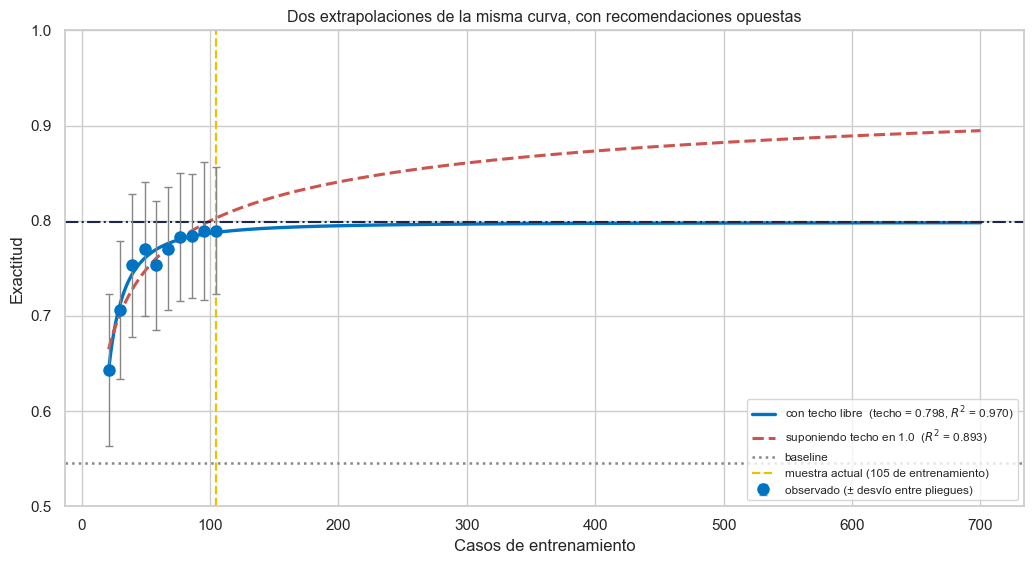

In [13]:
fig, ax = plt.subplots(figsize=(10.5, 5.8))
n_proy = np.linspace(tam_obs.min(), 700, 500)

ax.errorbar(tam_obs, 1 - error_obs, yerr=te_obs.std(axis=1), fmt="o", ms=8,
            color=PALETA[0], ecolor=PALETA[3], elinewidth=1, capsize=3, zorder=5,
            label="observado (± desvío entre pliegues)")
ax.plot(n_proy, 1 - ley_con_techo(n_proy, *par_techo), "-", lw=2.4, color=PALETA[0],
        label=f"con techo libre  (techo = {1-c:.3f}, $R^2$ = {r2_con:.3f})")
ax.plot(n_proy, 1 - ley_sin_techo(n_proy, *par_sin), "--", lw=2.2, color=PALETA[2],
        label=f"suponiendo techo en 1.0  ($R^2$ = {r2_sin:.3f})")
ax.axhline(1 - c, color=PALETA[4], ls="-.", lw=1.5)
ax.axhline(y_2.value_counts(normalize=True).iloc[0], color=PALETA[3], ls=":", lw=1.8,
           label="baseline")
ax.axvline(tam_obs[-1], color=PALETA[1], ls="--", lw=1.6,
           label=f"muestra actual ({int(tam_obs[-1])} de entrenamiento)")

ax.set_xlabel("Casos de entrenamiento")
ax.set_ylabel("Exactitud")
ax.set_ylim(0.5, 1.0)
ax.set_title("Dos extrapolaciones de la misma curva, con recomendaciones opuestas",
             fontsize=11.5)
ax.legend(fontsize=8.5, loc="lower right")
plt.tight_layout()
plt.show()

### Las dos extrapolaciones no dicen lo mismo

- **Con el techo libre** el ajuste describe muy bien lo observado ($R^2 \approx 0.97$) y ubica el
  límite asintótico alrededor de **0.80**. Como hoy estamos en 0.790, la conclusión es que **ya
  estamos prácticamente en el techo**: duplicar la muestra ganaría menos de un punto.
- **Suponiendo que el error puede llegar a cero** el ajuste es peor ($R^2 \approx 0.89$) y proyecta
  que con unos 240 casos se alcanzaría 0.85 y con unos 470 se llegaría a 0.88.

Los dos ajustes describen razonablemente los mismos diez puntos observados y **recomiendan
decisiones opuestas**: uno dice "no gastes en más encuestas", el otro dice "triplicá la muestra".
La única forma de distinguirlos sería tener datos más allá del rango observado, que es exactamente
lo que no tenemos. Extrapolar una curva de aprendizaje es siempre así.

El ajuste con techo libre es preferible por dos razones: describe mejor los datos, y su supuesto es
el razonable —ningún modelo predice la identificación política sin error, porque la identificación
política no es una función determinística de trece opiniones—. Pero la distancia entre las dos
curvas es la medida honesta de cuánto **no** sabemos.

### El producto

Lo que se lleva quien tiene que decidir sobre el próximo relevamiento:

1. **Con 132 casos el techo ya está cerca.** El ajuste que mejor describe la curva estima un límite
   asintótico de **0.80**, y la muestra actual ya rinde **0.790**. La recomendación es **no**
   invertir en más casos del mismo tipo.
2. **El cuello de botella no es el método, son las variables.** Cinco familias de modelos con
   supuestos completamente distintos —lineal penalizado, árbol, bagging, boosting adaptativo,
   gradient boosting— convergen al mismo número. Cuando eso pasa, agregar métodos no sirve: hay que
   agregar **información**. Para mejorar de verdad hay que preguntar otras cosas, no encuestar a
   más gente sobre lo mismo.
3. **Para el modelo de producción, usar el logit de `9.2`.** Empata con el bosque, se explica con
   odds ratios, corre instantáneamente y se puede auditar. Un Random Forest de 500 árboles que
   iguala a un modelo lineal es una complejidad que no se paga.
4. **Y una recomendación de muestreo**: si el objetivo es distinguir las siete etiquetas y no solo
   peronismo/resto, el problema no es el modelo sino el diseño. Habría que **sobremuestrear
   deliberadamente** las etiquetas chicas —radicales, derecha, liberales— para tener al menos 30
   casos de cada una, en lugar de aumentar el tamaño total de forma proporcional.

## Síntesis

1. **La relación p/n es la que gobierna todo.** En `9.3` había 117 observaciones por columna de la
   matriz de diseño; acá hay 2.4.

2. **La curva de validación sobre `max_depth` es plana dentro del ruido**: con esta muestra no se
   puede calibrar la complejidad del modelo. En `9.3` la misma figura tenía un máximo nítido.

3. **El árbol es completamente inestable**: la variable de la raíz cambia entre remuestreos de los
   mismos datos. La estructura de un árbol sobre 132 casos no constituye un hallazgo.

4. **Random Forest empata con el logit regularizado** (~0.79 los dos), los árboles individuales
   quedan 13 puntos abajo y XGBoost queda por detrás del bosque. El veredicto de `9.3` se invirtió.

5. Ese empate **es un hallazgo sobre los datos**: dice que la relación es aproximadamente lineal en
   el logit, sin las interacciones fuertes que sí había en los datos electorales.

6. Con 7 clases, **un árbol único queda por debajo del baseline**. Intentar discriminar con una o
   dos observaciones por clase es peor que no intentarlo; el bagging lo corrige promediando.

7. `TARIFAS` encabeza la importancia por permutación, la misma variable que dominaba en `9.2` con
   maquinaria completamente distinta. Pero **las barras de error cruzan el cero**: con 47 casos de
   validación, la importancia individual se estima con mucho ruido.

8. El cierre no es una métrica: es una **recomendación de diseño de muestra**, con la extrapolación
   hecha de dos maneras para mostrar cuánto no se sabe.

## La lección conjunta

| | `9.3` · mesas | `9.3b` · encuesta (este) |
|---|---|---|
| Casos | 7.233 | 132 |
| Observaciones por columna | 117 | 2.4 |
| Baseline | 0.503 | 0.545 |
| Árbol único, mejor versión | 0.749 | ~0.67 |
| Random Forest | 0.772 | ~0.79 |
| XGBoost | **0.775** | ~0.76 |
| Modelo lineal | 0.757 | **~0.79** |
| ¿Ganan los ensambles? | **sí**, por ~2 puntos | **no**, empatan |
| ¿Se puede calibrar la complejidad? | sí, con un óptimo nítido | no, la curva es ruido |
| ¿Es estable el árbol? | la raíz sí | nada |

Los dos notebooks usan los mismos métodos y casi el mismo código. Lo único que cambia de fondo es
la cantidad de datos, y **el veredicto se invierte**.

De ahí la moraleja práctica: *"¿conviene usar un ensamble?"* no tiene respuesta en abstracto. Es
una pregunta sobre la relación entre la complejidad del modelo y la información disponible — el
compromiso sesgo-varianza de `9.0`, visto desde el ángulo del diseño de investigación.

Y para el trabajo cotidiano en opinión pública, donde las muestras se parecen mucho más a 132 que
a 7.233, la respuesta por defecto es: **empezar por el modelo lineal regularizado, y exigirle al
ensamble que demuestre que gana.**

## Lo que sigue

Termina el bloque supervisado. En `9.4` desaparece la etiqueta: pasamos al **aprendizaje no
supervisado**, donde no hay respuesta correcta contra la que medirse y el criterio del investigador
vuelve al centro.